In [2]:
import scanpy as sc
import omicverse as ov
ov.plot_set()

2024-11-24 16:26:57.660714: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-24 16:26:57.674462: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-24 16:26:57.678703: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-24 16:26:58.376808: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT



   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

Version: 1.6.9, Tutorials: https://omicverse.readthedocs.io/
Dependency error: (pydeseq2 0.4.11 (/mnt/home/zehuazeng/software/rsc/lib/python3.10/site-packages), Requirement.parse('pydeseq2<=0.4.0,>=0.3'))


In [2]:
adata_sp_gas=sc.read_visium('/mnt/data/zehuazeng/result/GC_ST/HRR742264/HRR742264/outs/')
adata_sp_gas.obs.index=[f'gas:{i}' for i in adata_sp_gas.obs.index]

reading /mnt/data/zehuazeng/result/GC_ST/HRR742264/HRR742264/outs/filtered_feature_bc_matrix.h5
 (0:00:00)


In [3]:
adata_sp_gc=sc.read_visium('data/GC_ST/GSE245704_RAW')
adata_sp_gc.obs.index=[f'gc:{i}' for i in adata_sp_gc.obs.index]

reading data/GC_ST/GSE245704_RAW/filtered_feature_bc_matrix.h5
 (0:00:00)


In [4]:
adata_sp_gc.var_names_make_unique()
adata_sp_gas.var_names_make_unique()

In [5]:
adata_sp_gas,adata_sp_gc

(AnnData object with n_obs × n_vars = 2325 × 36601
     obs: 'in_tissue', 'array_row', 'array_col'
     var: 'gene_ids', 'feature_types', 'genome'
     uns: 'spatial'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 2560 × 18085
     obs: 'in_tissue', 'array_row', 'array_col'
     var: 'gene_ids', 'feature_types', 'genome'
     uns: 'spatial'
     obsm: 'spatial')

In [6]:
adatas_cor=[adata_sp_gas,adata_sp_gc]

In [7]:
adata_spatial = sc.concat(
    adatas_cor,
    label="library_id",
    uns_merge="unique",
    keys=[
        k
        for d in [
            adatas_cor[0].uns["spatial"],
            adatas_cor[1].uns["spatial"],
        ]
        for k, v in d.items()
    ],
    #index_unique="-",
)
adata_spatial.obs.head()

,in_tissue,array_row,array_col,library_id
gas:AAACAAGTATCTCCCA-1,1,50,102,HRR742264
gas:AAACCGGAAATGTTAA-1,1,54,124,HRR742264
gas:AAACCGGGTAGGTACC-1,1,42,28,HRR742264
gas:AAACCGTTCGTCCAGG-1,1,52,42,HRR742264
gas:AAACCTAAGCAGCCGG-1,1,65,83,HRR742264


In [8]:
adata_spatial.uns['spatial'].keys()

dict_keys(['HRR742264', '2'])

In [9]:
adata_spatial

AnnData object with n_obs × n_vars = 4885 × 18085
    obs: 'in_tissue', 'array_row', 'array_col', 'library_id'
    uns: 'spatial'
    obsm: 'spatial'

In [10]:
from omicverse.externel import BINARY

In [11]:
adata = BINARY.clean_adata(adata_spatial, save_obs=['in_tissue', 'library_id'])

In [12]:
adata = BINARY.Count2Binary(adata)

In [13]:
BINARY.Mutil_Construct_Spatial_Graph(adata,
                                     use_method='KNN',
                                     cutoff=14,
                                     obs_key='library_id',
                                     use_list=None)

------Constructing spatial graph...------
The graph contains 32550 edges, 2325 cells.
14.0000 neighbors per cell on average.
------Constructing spatial graph...------
The graph contains 35840 edges, 2560 cells.
14.0000 neighbors per cell on average.


AnnData object with n_obs × n_vars = 4885 × 18085
    obs: 'in_tissue', 'library_id'
    uns: 'spatial', 'Spatial_Graph'
    obsm: 'spatial'

In [14]:
import numpy as np
section_list = np.unique(adata.obs['library_id'])
section_list

array(['2', 'HRR742264'], dtype=object)

In [15]:
adata = BINARY.train_BINARY(adata, pos_weight= 10, device = 'cuda:0')

Size of Input:  (4885, 18085)


100%|██████████| 1000/1000 [01:15<00:00, 13.27it/s]


In [16]:
adata

AnnData object with n_obs × n_vars = 4885 × 18085
    obs: 'in_tissue', 'library_id'
    uns: 'spatial', 'Spatial_Graph'
    obsm: 'spatial', 'BINARY'

In [17]:
sc.pp.neighbors(adata, use_rep='BINARY')
sc.tl.umap(adata)

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:05)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:05)


In [ ]:
sc.pl.embedding(adata,
               basis='X_umap',
               color=['library_id','mclust'])

In [30]:
adata.X.max()

1.0

In [32]:
adata_spatial.obsm=adata.obsm.copy()
adata_spatial.obs=adata.obs.copy()

In [34]:
adata_spatial.X.max()

10496.0

In [35]:
sc.pp.normalize_total(adata_spatial, target_sum=1e4, 
                      inplace=True)
sc.pp.log1p(adata_spatial)

normalizing counts per cell
    finished (0:00:00)


Storing dendrogram info using `.uns['dendrogram_mclust']`


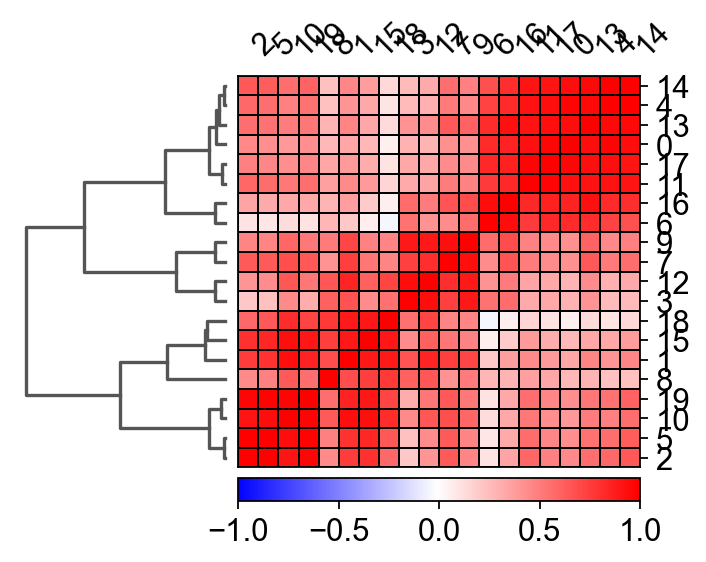

In [36]:
sc.tl.dendrogram(adata_spatial,groupby='mclust',use_rep='BINARY',)
ax = sc.pl.correlation_matrix(adata_spatial, 
                              "mclust", 
                              figsize=(5, 3.5))

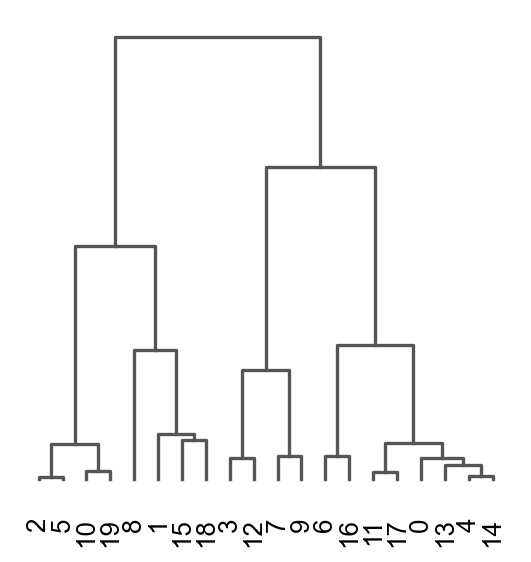

In [39]:
ax = sc.pl.dendrogram(adata_spatial,groupby='mclust',)

In [41]:
adata_spatial.uns['dendrogram_mclust']

{'linkage': array([[2.00000000e+00, 5.00000000e+00, 5.22000519e-03, 2.00000000e+00],
        [4.00000000e+00, 1.40000000e+01, 7.40622607e-03, 2.00000000e+00],
        [1.10000000e+01, 1.70000000e+01, 1.62597419e-02, 2.00000000e+00],
        [1.00000000e+01, 1.90000000e+01, 1.94180725e-02, 2.00000000e+00],
        [1.30000000e+01, 2.10000000e+01, 3.42309739e-02, 3.00000000e+00],
        [0.00000000e+00, 2.40000000e+01, 4.96624083e-02, 4.00000000e+00],
        [3.00000000e+00, 1.20000000e+01, 5.09842087e-02, 2.00000000e+00],
        [6.00000000e+00, 1.60000000e+01, 5.44727717e-02, 2.00000000e+00],
        [7.00000000e+00, 9.00000000e+00, 5.51728544e-02, 2.00000000e+00],
        [2.00000000e+01, 2.30000000e+01, 8.20155031e-02, 4.00000000e+00],
        [2.20000000e+01, 2.50000000e+01, 8.50076001e-02, 6.00000000e+00],
        [1.50000000e+01, 1.80000000e+01, 9.20844197e-02, 2.00000000e+00],
        [1.00000000e+00, 3.10000000e+01, 1.05133052e-01, 3.00000000e+00],
        [2.60000000e+01, 2.

In [56]:
import numpy as np
from scipy.cluster.hierarchy import fcluster

# 你的链接矩阵
linkage_matrix = adata_spatial.uns['dendrogram_mclust']['linkage']

# 选择一个阈值来确定簇
threshold = 0.05  # 这个值需要根据具体情况调整

# 使用fcluster来合并类别
clusters = fcluster(linkage_matrix, threshold, criterion='distance')

# 创建字典
cluster_dict = {}
for idx, cluster_id in enumerate(clusters):
    key = f'c{cluster_id}'
    if key not in cluster_dict:
        cluster_dict[key] = []
    cluster_dict[key].append(idx)

print(cluster_dict)

{'c14': [0, 4, 13, 14], 'c5': [1], 'c1': [2, 5], 'c7': [3], 'c11': [6], 'c9': [7], 'c6': [8], 'c10': [9], 'c2': [10, 19], 'c13': [11, 17], 'c8': [12], 'c3': [15], 'c12': [16], 'c4': [18]}


In [57]:
reversed_dict = {}
for key, values in cluster_dict.items():
    for value in values:
        reversed_dict[value] = key

print(reversed_dict)

{0: 'c14', 4: 'c14', 13: 'c14', 14: 'c14', 1: 'c5', 2: 'c1', 5: 'c1', 3: 'c7', 6: 'c11', 7: 'c9', 8: 'c6', 9: 'c10', 10: 'c2', 19: 'c2', 11: 'c13', 17: 'c13', 12: 'c8', 15: 'c3', 16: 'c12', 18: 'c4'}


In [58]:
adata.obs['mclust_tree']=adata.obs['mclust'].map(reversed_dict)

In [59]:
ov.utils.cluster(adata,use_rep='BINARY',method='mclust',n_components=20,
                 modelNames='EEV', random_state=112,
                )
#adata.obs['mclust_GraphST'] = ov.utils.refine_label(adata, radius=50, key='mclust') 

running GaussianMixture clustering
finished: found 20 clusters and added
    'mclust', the cluster labels (adata.obs, categorical)


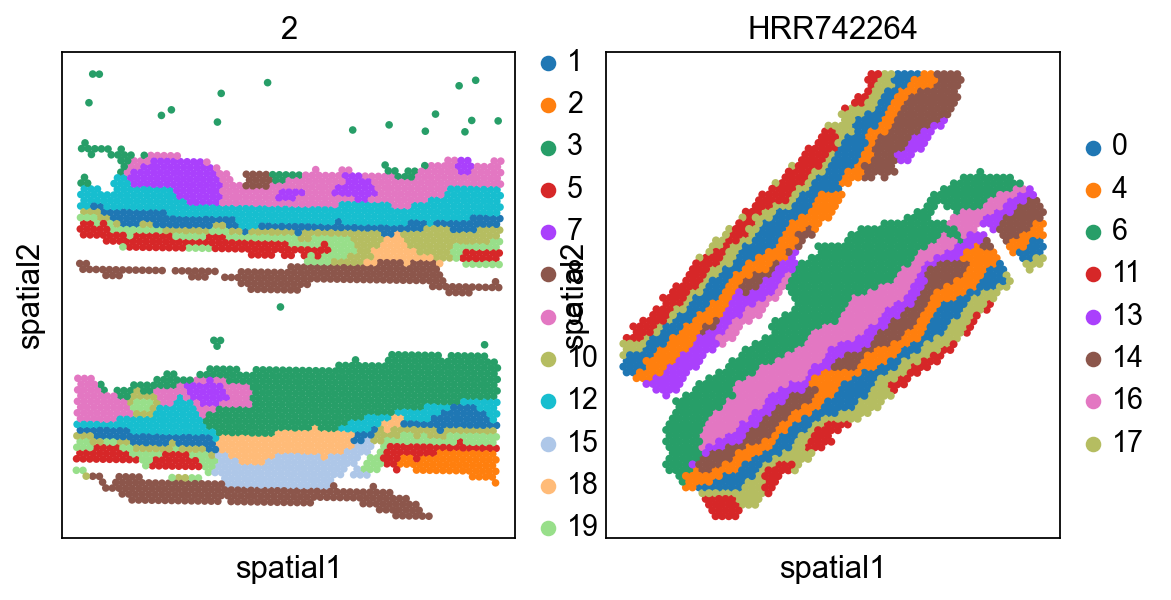

In [20]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
it=0
for it,section_id in enumerate(section_list):
    ax = sc.pl.embedding(adata[adata.obs['library_id']==section_id], basis='spatial', ax=axs[it], #legend_loc=None,
                      color=["mclust"], title=section_id, show=False)
    ax.axis('equal')

In [60]:
adata_sp_gas.obs['mclust']=adata.obs.loc[adata_sp_gas.obs.index,'mclust_tree'].tolist()
adata_sp_gc.obs['mclust']=adata.obs.loc[adata_sp_gc.obs.index,'mclust_tree'].tolist()

In [61]:
adata_sp_gas.obs['mclust']=adata_sp_gas.obs['mclust'].astype(str)
adata_sp_gc.obs['mclust']=adata_sp_gc.obs['mclust'].astype(str)

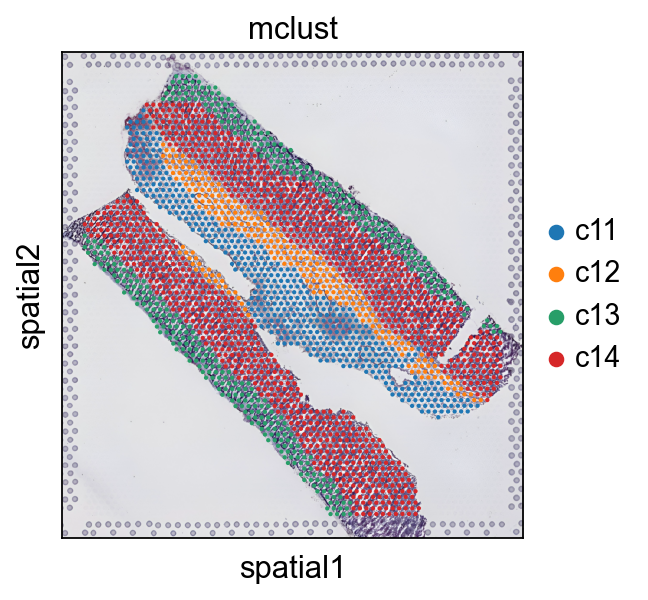

In [62]:
sc.pl.spatial(adata_sp_gas, color=['mclust'])

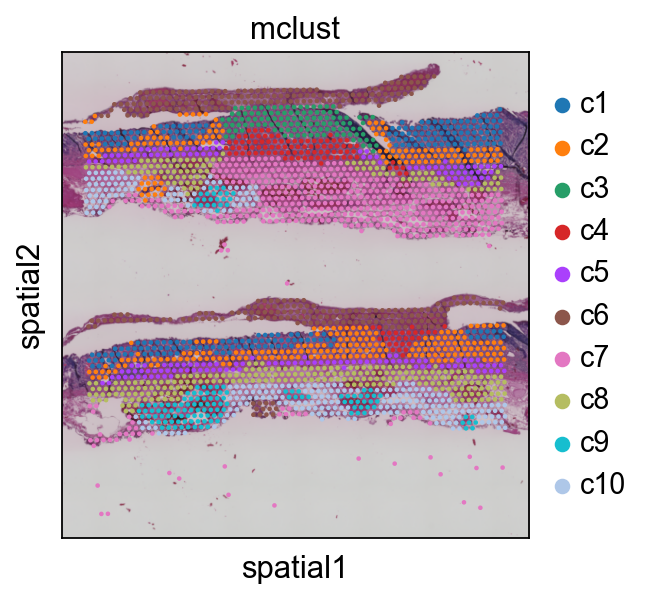

In [63]:
sc.pl.spatial(adata_sp_gc, color=['mclust'])

In [64]:
adata_sp_gas.write('data/GC_ST/GAS_ST_mclust.h5ad',compression='gzip')
adata_sp_gc.write('data/GC_ST/GC_ST_mclust.h5ad',compression='gzip')

In [3]:
adata_sp_gas=sc.read('data/GC_ST/GAS_ST_mclust.h5ad',compression='gzip')
adata_sp_gc=sc.read('data/GC_ST/GC_ST_mclust.h5ad',compression='gzip')

In [5]:
adata_sp_gas=ov.pp.preprocess(adata_sp_gas,mode='shiftlog|pearson',n_HVGs=3000,target_sum=50*1e4)
adata_sp_gc=ov.pp.preprocess(adata_sp_gc,mode='shiftlog|pearson',n_HVGs=3000,target_sum=50*1e4)

Begin robust gene identification
After filtration, 21439/36601 genes are kept.     Among 21439 genes, 19584 genes are robust.
End of robust gene identification.
Begin size normalization: shiftlog and HVGs selection pearson
normalizing counts per cell. The following highly-expressed genes are not considered during normalization factor computation:
['GKN1', 'LIPF', 'PGA5']
    finished (0:00:00)
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'highly_variable_nbatches', int vector (adata.var)
    'highly_variable_intersection', boolean vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'residual_variances', float vector (adata.var)
Time to analyze data in cpu: 1.4005866050720215 seconds.
End of size normalization: shiftlog and HVGs selection pearson
Begin robust gene identification
After filtration, 18055/18085 genes are kept.     Among

computing PCA
    with n_comps=50
    finished (0:00:23)
Storing dendrogram info using `.uns['dendrogram_mclust']`
ranking genes
    finished: added to `.uns['mclust_ttest']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


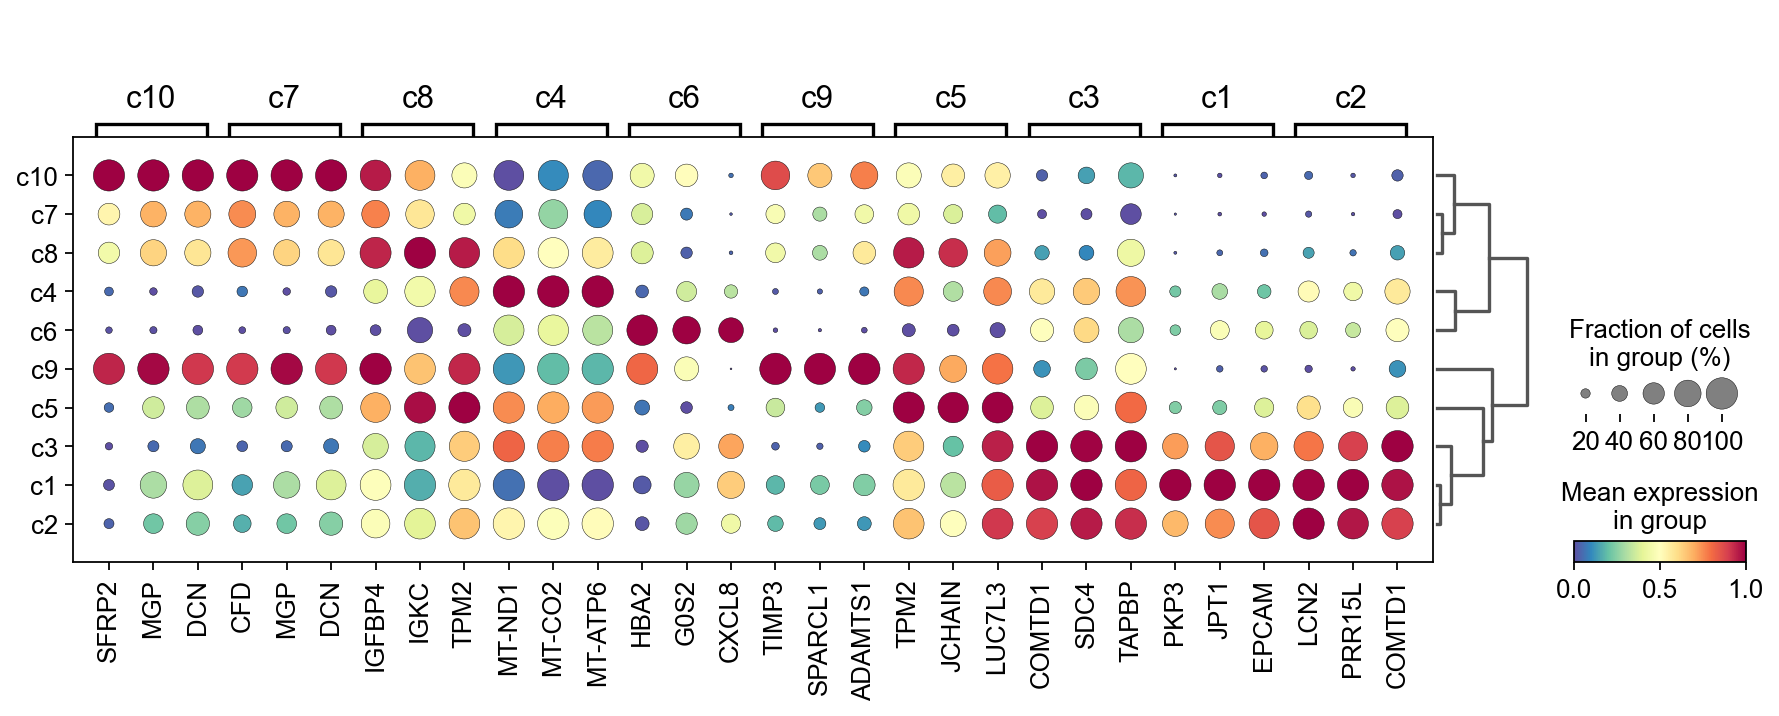

In [25]:
sc.tl.dendrogram(adata_sp_gc,'mclust',#use_rep='BINARY'
                )
sc.tl.rank_genes_groups(adata_sp_gc, 'mclust', #use_rep='BINARY',
                        method='t-test',use_raw=False,key_added='mclust_ttest')
sc.pl.rank_genes_groups_dotplot(adata_sp_gc,groupby='mclust',
                                cmap='Spectral_r',key='mclust_ttest',
                                standard_scale='var',n_genes=3)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
**finished identifying marker genes by COSG**


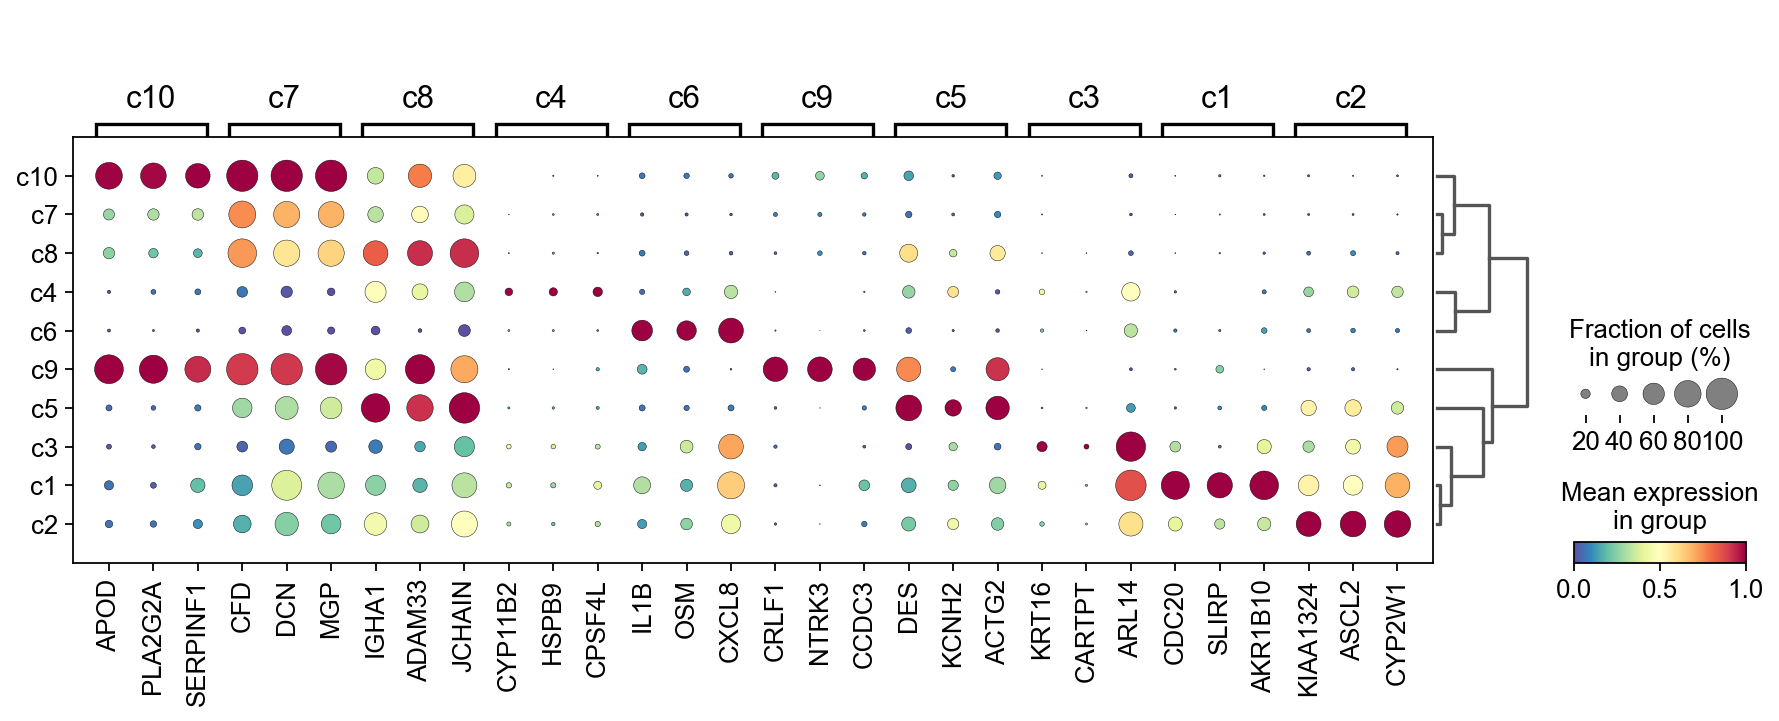

In [28]:
sc.tl.rank_genes_groups(adata_sp_gc, groupby='mclust', 
                        method='t-test',)

ov.single.cosg(adata_sp_gc, key_added='mclust_cosg', groupby='mclust')
sc.pl.rank_genes_groups_dotplot(adata_sp_gc,groupby='mclust',
                                cmap='Spectral_r',key='mclust_cosg',
                                standard_scale='var',n_genes=3)

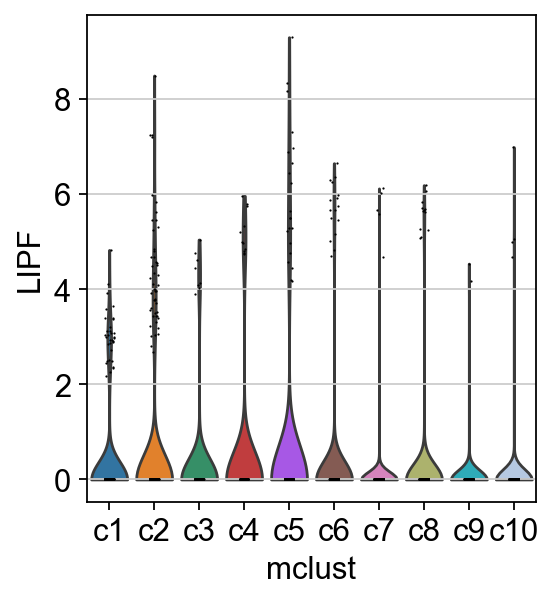

In [33]:
sc.pl.violin(adata_sp_gc,'LIPF',groupby='mclust')

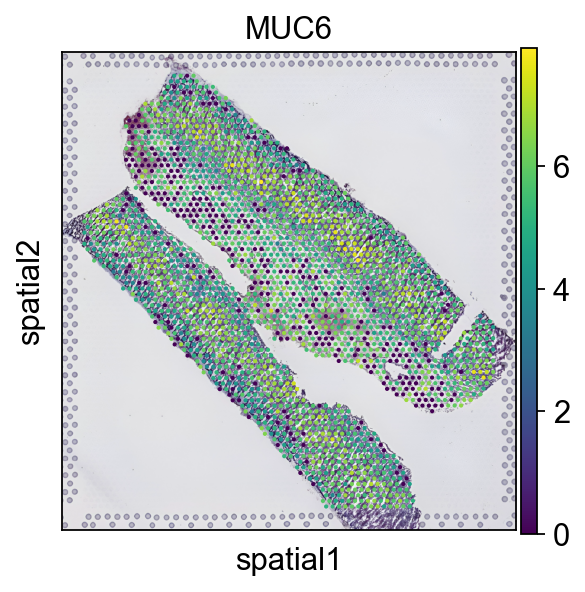

In [19]:
sc.pl.spatial(adata_sp_gas, color=['MUC6'])

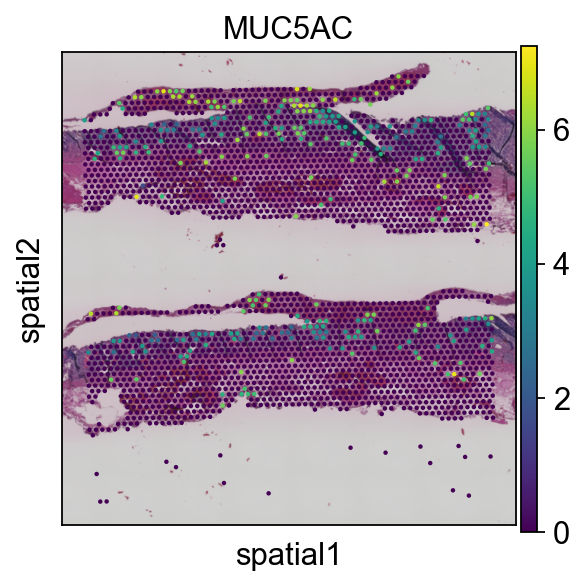

In [23]:
sc.pl.spatial(adata_sp_gc, color=['MUC5AC'])

In [43]:
cluster_type_dict_gas=dict(zip(
    ['c11','c12','c13','c14'],
    ['Fibro Layer','Chief Layer','Foveolar Layer','Neck Layer'],
))

cluster_type_dict_gc=dict(zip(
    ['c1','c2','c3','c4','c5','c6','c7','c8','c9','c10'],
    ['Foveolar Layer','Neck Layer','Foveolar Layer','Tumor','Chief Layer','Tumor',
     'Fibro Layer','Fibro Layer','Vessel','Fibro Layer'
    ],
))

adata_sp_gas.obs['Layer']=adata_sp_gas.obs['mclust'].map(cluster_type_dict_gas)
adata_sp_gc.obs['Layer']=adata_sp_gc.obs['mclust'].map(cluster_type_dict_gc)

In [46]:
fb=ov.pl.ForbiddenCity()
from IPython.display import HTML
HTML(fb.visual_color(loc_range=(0,384),
                    num_per_row=24))

人籁,青粲,翠缥,水龙吟,碧山,石发,菉竹,庭芜绿,葱倩,漆姑,翠微,芰荷,青青,翠虬,官绿,油绿,莓莓,螺青,春辰,麴尘,欧碧,苍葭,兰苕,青玉案
,,,,,,,,,,,,,,,,,,,,,,,
碧滋,瓷秘,筠雾,竹香子,鸣珂,琬琰,出岫,王刍,春碧,执大象,青圭,绿沈,风入松,荩篋,绞衣,素綦,苍筤,天缥,卵色,沧浪,葭菼,山岚,冰台,青古
,,,,,,,,,,,,,,,,,,,,,,,
醽醁,渌波,青楸,缥碧,翠涛,青梅,雀梅,苔古,蕉月,干山翠,翕赩,结绿,绿云,丹罽,黄丹,檎丹,银朱,洛神珠,珊瑚赫,朱孔阳,丹雘,水华朱,胭脂虫,朱樱
,,,,,,,,,,,,,,,,,,,,,,,
大繎,顺圣,爵头,麒麟竭,苕荣,扶光,十样锦,海天霞,驿刚,朱颜酡,赦霞,赦尾,缙云,小红,琼琚,岱赭,朱柿,艳炽,鹤顶红,赤缇,纁黄,棠梨,朱殷,石榴裙
,,,,,,,,,,,,,,,,,,,,,,,
朱草,赤灵,佛赤,綪茷,朱湛,丹秫,木兰,杨妃,盈盈,银红,粉米,桃夭,水红,夕岚,彤管,咸池,莲红,雌霓,縓缘,长春,渥赭,红䵂,紫梅,绛纱
,,,,,,,,,,,,,,,,,,,,,,,
茹藘,美人祭,唇脂,牙绯,鞓红,葡萄褐,蚩尤旗,紫矿,紫诰,苏方,霁红,蜜褐,福色,黪紫,龙膏烛,苏梅,琅环紫,胭脂水,紫茎屏风,红踯躅,胭脂紫,魏红,紫府,魏紫


In [90]:
color_dict={
    'Foveolar Layer':fb.get_color(name='木兰')['color_html'].values[0],
    'Neck Layer':fb.get_color(name='肉红')['color_html'].values[0],
    'Chief Layer':fb.get_color(name='苕荣')['color_html'].values[0],
    'Tumor':fb.get_color(name='赪紫')['color_html'].values[0],
    'Fibro Layer':fb.get_color(name='紫蒲')['color_html'].values[0],
    'Vessel':fb.get_color(name='丹雘')['color_html'].values[0],
}

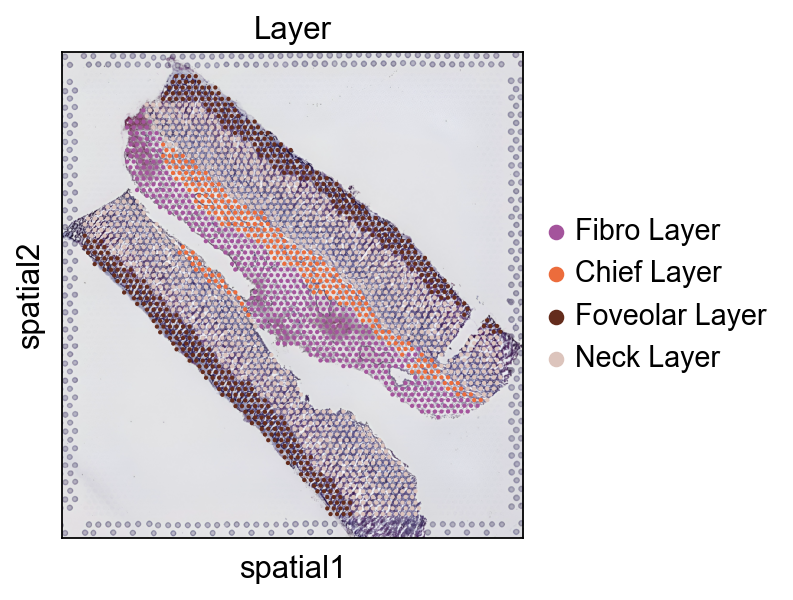

In [91]:
sc.pl.spatial(adata_sp_gas, color=['Layer'],
             palette=color_dict)

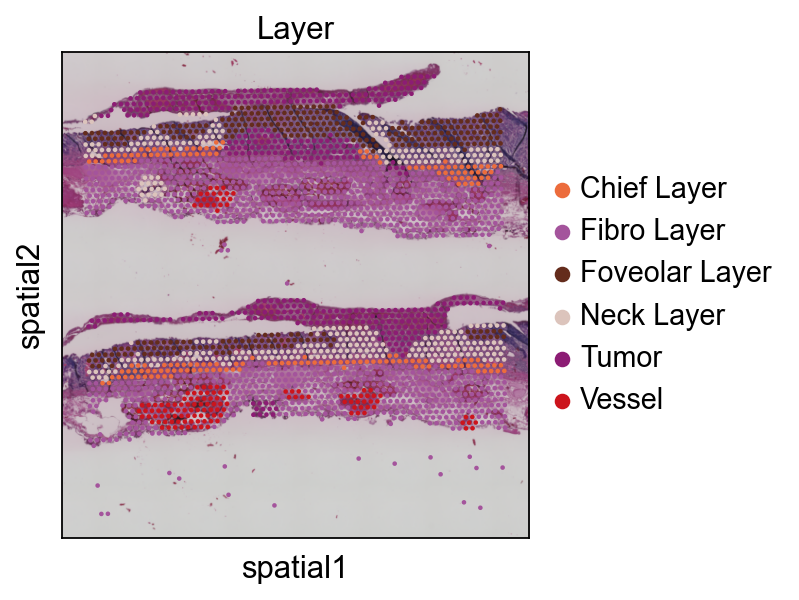

In [92]:
sc.pl.spatial(adata_sp_gc, color=['Layer'],
             palette=color_dict)

In [95]:
adata_sp_gas.write('data/GC_ST/GAS_ST_anno.h5ad',compression='gzip')
adata_sp_gc.write('data/GC_ST/GC_ST_anno.h5ad',compression='gzip')

In [94]:
1

1